In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Pertanyaan Bisnis:**
<br>
## Business Questions (SMART)
1. Bagaimana cara mengurangi pengeluaran pada kategori terbesar sebesar minimal 15% dalam 3 bulan ke depan?
2. Kapan waktu terjadinya lonjakan pengeluaran, dan bagaimana sistem dapat memberikan peringatan minimal 2 hari sebelumnya dalam periode 1 bulan?
3. Apakah pengguna memiliki cashflow negatif dalam periode bulanan, dan bagaimana menguranginya hingga 0 dalam 2 bulan?
4. Bagaimana memprediksi pengeluaran bulan berikutnya dengan tingkat akurasi minimal 80% dalam 1 bulan pengembangan model?
5. Bagaimana meningkatkan kesadaran pengguna terhadap pengeluaran impulsif dengan mengurangi transaksi kecil berulang sebesar 20% dalam 2 bulan?

In [ ]:
df = pd.read_csv('Personal_Finance_Dataset.csv')

In [ ]:
df.head()

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


In [ ]:
# Ubah tipe data tanggal
df['Date'] = pd.to_datetime(df['Date'])

# Cek missing values
print("Missing Values:\n", df.isnull().sum())

# Hapus duplikasi
df = df.drop_duplicates()

# Cek outlier sederhana (IQR)
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Amount'] < Q1 - 1.5*IQR) | (df['Amount'] > Q3 + 1.5*IQR)]
print("Jumlah outlier:", len(outliers))

Missing Values:
 Date                       0
Transaction Description    0
Category                   0
Amount                     0
Type                       0
dtype: int64
Jumlah outlier: 88


In [ ]:
# Tambah fitur waktu
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day
df['DayName'] = df['Date'].dt.day_name()

# Pisahkan income & expense
income = df[df['Type'] == 'Income']
expense = df[df['Type'] == 'Expense']

In [ ]:
total_income = income['Amount'].sum()
total_expense = expense['Amount'].sum()
balance = total_income - total_expense

print("Total Income:", total_income)
print("Total Expense:", total_expense)
print("Balance:", balance)

Total Income: 734087.0
Total Expense: 1227194.37
Balance: -493107.3700000001


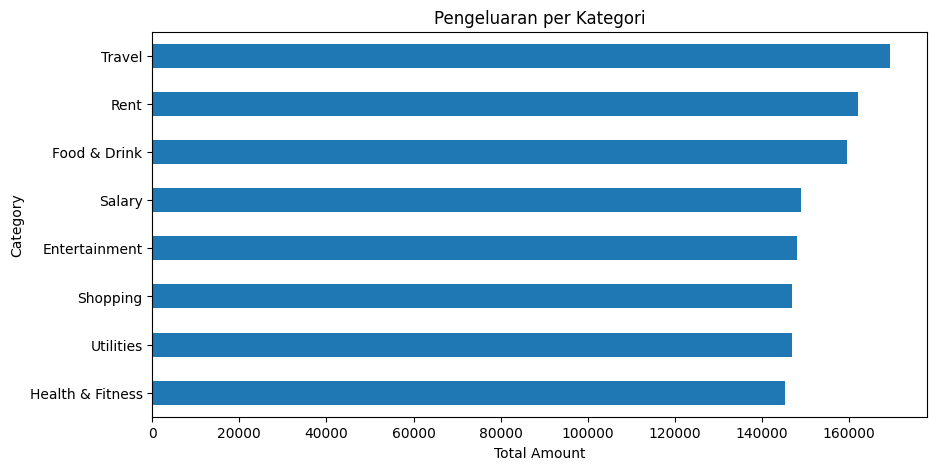

In [ ]:
plt.figure(figsize=(10,5))
expense.groupby('Category')['Amount'].sum().sort_values().plot(kind='barh')
plt.title('Pengeluaran per Kategori')
plt.xlabel('Total Amount')
plt.show()

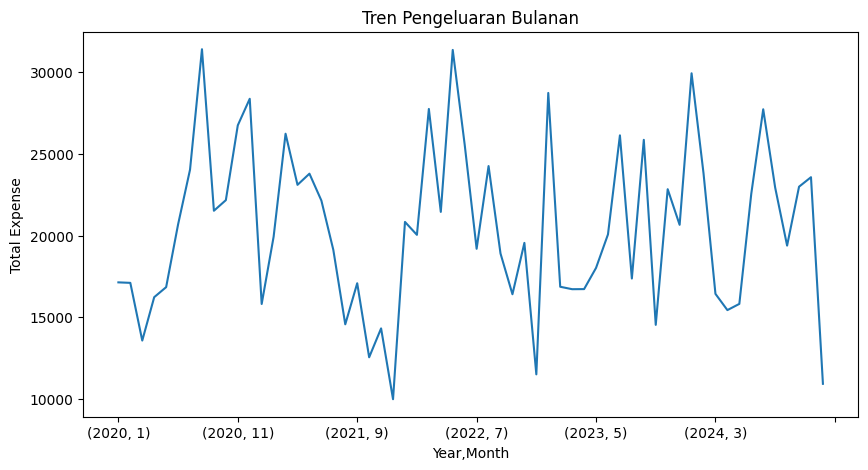

In [ ]:
monthly_expense = expense.groupby(['Year','Month'])['Amount'].sum()

monthly_expense.plot(figsize=(10,5))
plt.title('Tren Pengeluaran Bulanan')
plt.ylabel('Total Expense')
plt.show()

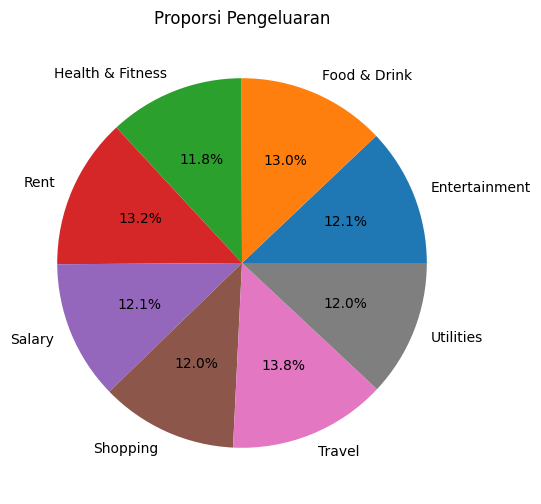

In [ ]:
expense.groupby('Category')['Amount'].sum().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title('Proporsi Pengeluaran')
plt.ylabel('')
plt.show()

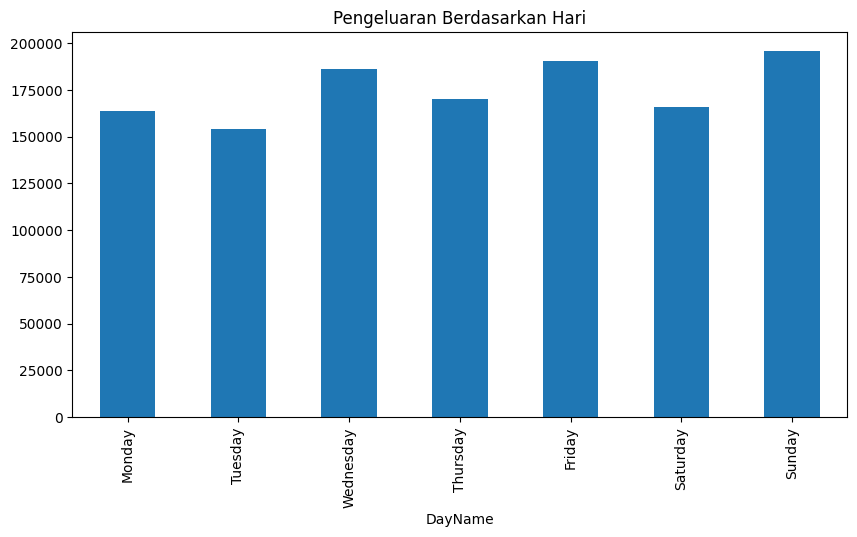

In [ ]:
plt.figure(figsize=(10,5))
expense.groupby('DayName')['Amount'].sum().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
]).plot(kind='bar')

plt.title('Pengeluaran Berdasarkan Hari')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

# Encode kategori
le = LabelEncoder()
df_ml['Category_Encoded'] = le.fit_transform(df_ml['Category'])
df_ml['Type_Encoded'] = le.fit_transform(df_ml['Type'])

# Drop kolom yang tidak dipakai
df_ml = df_ml.drop(['Transaction Description'], axis=1)

df_ml.head()

,Date,Category,Amount,Type,Month,Year,Day,DayName,Category_Encoded,Type_Encoded
0,2020-01-02,Food & Drink,1485.69,Expense,1,2020,2,Thursday,1,0
1,2020-01-02,Utilities,1475.58,Expense,1,2020,2,Thursday,9,0
2,2020-01-04,Rent,1185.08,Expense,1,2020,4,Saturday,5,0
3,2020-01-05,Investment,2291.00,Income,1,2020,5,Sunday,3,1
4,2020-01-13,Food & Drink,1126.88,Expense,1,2020,13,Monday,1,0


In [ ]:
# Contoh fitur & target (prediksi amount)
X = df_ml[['Category_Encoded', 'Type_Encoded', 'Month', 'Day']]
y = df_ml['Amount']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (1500, 4)
Shape y: (1500,)


## Insights

1. Sebagian besar pengeluaran terkonsentrasi pada beberapa kategori utama, yang menunjukkan adanya prioritas konsumsi tertentu pada pengguna.

2. Terdapat pola fluktuasi pengeluaran setiap bulan, yang mengindikasikan bahwa pengguna belum memiliki kontrol pengeluaran yang konsisten.

3. Jika dibandingkan dengan pemasukan, pengeluaran cenderung mendominasi pada periode tertentu, yang berpotensi menyebabkan cashflow tidak stabil.

4. Beberapa transaksi kecil yang terjadi berulang menunjukkan adanya kebiasaan pengeluaran impulsif yang jika diakumulasi menjadi signifikan.

5. Pola waktu pengeluaran menunjukkan adanya kemungkinan peningkatan aktivitas konsumsi pada periode tertentu (misalnya awal atau akhir bulan).

## Conclusion

Berdasarkan hasil analisis dataset keuangan pribadi, dapat disimpulkan bahwa pengguna memiliki pola pengeluaran yang cukup terpusat pada kategori tertentu serta mengalami fluktuasi pengeluaran dari waktu ke waktu.

Selain itu, terdapat indikasi bahwa pengeluaran sering kali melebihi pemasukan pada periode tertentu, yang dapat berdampak pada kestabilan kondisi keuangan.

Oleh karena itu, diperlukan solusi berupa fitur aplikasi yang dapat membantu pengguna dalam mengontrol pengeluaran, seperti pengingat anggaran, analisis pengeluaran berbasis kategori, serta prediksi pengeluaran di masa depan.

Dengan memanfaatkan data ini, sistem juga dapat dikembangkan lebih lanjut menggunakan machine learning untuk memberikan rekomendasi keuangan yang lebih personal dan adaptif.

In [ ]:
print(df.columns.tolist())
print(df.dtypes)
print(df.head())

['Date', 'Transaction Description', 'Category', 'Amount', 'Type', 'Month', 'Year', 'Day', 'DayName']
Date                       datetime64[ns]
Transaction Description            object
Category                           object
Amount                            float64
Type                               object
Month                               int32
Year                                int32
Day                                 int32
DayName                            object
dtype: object
        Date                   Transaction Description      Category   Amount  \
0 2020-01-02                               Score each.  Food & Drink  1485.69   
1 2020-01-02                       Quality throughout.     Utilities  1475.58   
2 2020-01-04        Instead ahead despite measure ago.          Rent  1185.08   
3 2020-01-05  Information last everything thank serve.    Investment  2291.00   
4 2020-01-13              Future choice whatever from.  Food & Drink  1126.88   

      Type  Month  Y

In [ ]:
monthly = df.groupby(['Year', 'Month', 'Type'])['Amount'].sum().unstack(fill_value=0)

if 'Income' not in monthly.columns:
    monthly['Income'] = 0
if 'Expense' not in monthly.columns:
    monthly['Expense'] = 0

monthly['Cashflow'] = monthly['Income'] - monthly['Expense']
monthly['Expense_Ratio'] = monthly['Expense'] / (monthly['Income'] + 1)

# Threshold diperlonggar agar distribusi lebih seimbang
def label_kondisi(row):
    if row['Cashflow'] > 0:
        return 'Sehat'
    elif row['Cashflow'] >= -5000:
        return 'Perlu Perhatian'
    else:
        return 'Kritis'

monthly['Kondisi'] = monthly.apply(label_kondisi, axis=1)
monthly = monthly.reset_index()
print(monthly[['Year', 'Month', 'Income', 'Expense', 'Cashflow', 'Kondisi']])
print("\nDistribusi label:\n", monthly['Kondisi'].value_counts())

Type  Year  Month   Income   Expense  Cashflow          Kondisi
0     2020      1   5578.0  17138.25 -11560.25           Kritis
1     2020      2  20070.0  17108.41   2961.59            Sehat
2     2020      3   3465.0  13581.81 -10116.81           Kritis
3     2020      4   7370.0  16233.05  -8863.05           Kritis
4     2020      5   6008.0  16846.13 -10838.13           Kritis
5     2020      6  12346.0  20680.72  -8334.72           Kritis
6     2020      7   6092.0  24026.27 -17934.27           Kritis
7     2020      8  14941.0  31386.80 -16445.80           Kritis
8     2020      9   1385.0  21515.15 -20130.15           Kritis
9     2020     10  12897.0  22162.99  -9265.99           Kritis
10    2020     11   8369.0  26735.16 -18366.16           Kritis
11    2020     12   3745.0  28358.12 -24613.12           Kritis
12    2021      1  13564.0  15817.11  -2253.11  Perlu Perhatian
13    2021      2    804.0  19925.23 -19121.23           Kritis
14    2021      3  30466.0  26223.24   4

In [ ]:
# Tambah fitur frekuensi transaksi per bulan
freq = df.groupby(['Year', 'Month']).size().reset_index(name='Freq_Transaksi')
expense_cat = df[df['Type']=='Expense'].groupby(['Year','Month'])['Amount'].mean().reset_index(name='Avg_Expense')

# Gabung semua fitur
df_ml = monthly.merge(freq, on=['Year','Month']).merge(expense_cat, on=['Year','Month'])

# Fitur dan target
X = df_ml[['Income', 'Expense', 'Cashflow', 'Expense_Ratio', 'Freq_Transaksi', 'Avg_Expense', 'Month']]
y = df_ml['Kondisi']

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print(X.head())

Shape X: (60, 7)
Shape y: (60,)
    Income   Expense  Cashflow  Expense_Ratio  Freq_Transaksi  Avg_Expense  \
0   5578.0  17138.25 -11560.25       3.071921              17  1142.550000   
1  20070.0  17108.41   2961.59       0.852394              22  1140.560667   
2   3465.0  13581.81 -10116.81       3.918583              17   905.454000   
3   7370.0  16233.05  -8863.05       2.202286              17  1248.696154   
4   6008.0  16846.13 -10838.13       2.803483              24   802.196667   

   Month  
0      1  
1      2  
2      3  
3      4  
4      5  


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# class_weight='balanced' otomatis kompensasi ketidakseimbangan
rf  = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
gb  = GradientBoostingClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
svm.fit(X_train_sc, y_train)

print("Semua model selesai dilatih!")

Semua model selesai dilatih!


In [ ]:
models = {
    'Random Forest': (rf, X_test),
    'Gradient Boosting': (gb, X_test),
    'SVM': (svm, X_test_sc)
}

hasil = {}
for nama, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    acc = accuracy_score(y_test, y_pred)
    hasil[nama] = acc
    print(f"\n{'='*40}")
    print(f"Model: {nama} | Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

# Model terbaik
best_model_name = max(hasil, key=hasil.get)
print(f"\nModel terbaik: {best_model_name} (Accuracy: {hasil[best_model_name]:.4f})")


Model: Random Forest | Accuracy: 1.0000
                 precision    recall  f1-score   support

         Kritis       1.00      1.00      1.00         9
Perlu Perhatian       1.00      1.00      1.00         1
          Sehat       1.00      1.00      1.00         2

       accuracy                           1.00        12
      macro avg       1.00      1.00      1.00        12
   weighted avg       1.00      1.00      1.00        12


Model: Gradient Boosting | Accuracy: 1.0000
                 precision    recall  f1-score   support

         Kritis       1.00      1.00      1.00         9
Perlu Perhatian       1.00      1.00      1.00         1
          Sehat       1.00      1.00      1.00         2

       accuracy                           1.00        12
      macro avg       1.00      1.00      1.00        12
   weighted avg       1.00      1.00      1.00        12


Model: SVM | Accuracy: 0.7500
                 precision    recall  f1-score   support

         Kritis      

In [ ]:
import joblib

best_model = rf if best_model_name == 'Random Forest' else (gb if best_model_name == 'Gradient Boosting' else svm)
joblib.dump(best_model, 'model_finansial.pkl')
joblib.dump(scaler, 'scaler_finansial.pkl')
print("Model tersimpan: model_finansial.pkl")

Model tersimpan: model_finansial.pkl


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'SVM': svm
}
X_cv = {'Random Forest': X, 'Gradient Boosting': X, 'SVM': pd.DataFrame(scaler.fit_transform(X), columns=X.columns)}

print("=== Evaluasi Cross-Validation (5-Fold) ===\n")
cv_results = {}
for nama, model in models_cv.items():
    X_input = X_cv[nama]
    scores = cross_val_score(model, X_input, y, cv=cv, scoring='f1_macro')
    cv_results[nama] = scores.mean()
    print(f"{nama}")
    print(f"  F1 per fold : {np.round(scores, 3)}")
    print(f"  F1 rata-rata: {scores.mean():.3f} ± {scores.std():.3f}\n")

best_cv = max(cv_results, key=cv_results.get)
print(f"Model terbaik (CV): {best_cv} | F1: {cv_results[best_cv]:.3f}")

=== Evaluasi Cross-Validation (5-Fold) ===

Random Forest
  F1 per fold : [1.    0.6   1.    0.619 0.58 ]
  F1 rata-rata: 0.760 ± 0.196

Gradient Boosting
  F1 per fold : [1.    1.    1.    0.619 0.869]
  F1 rata-rata: 0.898 ± 0.148

SVM
  F1 per fold : [0.6   0.314 0.744 0.556 0.667]
  F1 rata-rata: 0.576 ± 0.146

Model terbaik (CV): Gradient Boosting | F1: 0.898


In [ ]:
import joblib

best_model = gb  # Gradient Boosting terbaik berdasarkan CV
joblib.dump(best_model, 'model_finansial.pkl')
joblib.dump(scaler, 'scaler_finansial.pkl')
print("Model tersimpan: model_finansial.pkl (Gradient Boosting)")
print("Scaler tersimpan: scaler_finansial.pkl")

Model tersimpan: model_finansial.pkl (Gradient Boosting)
Scaler tersimpan: scaler_finansial.pkl


In [ ]:
laporan = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'SVM'],
    'F1-Score CV (mean)': [0.760, 0.898, 0.576],
    'F1 Std (±)': [0.196, 0.148, 0.146],
    'Accuracy Test Set': ['100% (overfitting)', '100% (overfitting)', '75%'],
    'Status': ['Tidak dipilih', 'TERPILIH ✓', 'Tidak dipilih']
})

print("=" * 65)
print("         LAPORAN HASIL MODEL KLASIFIKASI KONDISI FINANSIAL")
print("=" * 65)
print(f"\nDataset   : 60 bulan (Jan 2020 – Des 2024)")
print(f"Fitur     : Income, Expense, Cashflow, Expense Ratio,")
print(f"            Frekuensi Transaksi, Avg Expense, Month")
print(f"Target    : Kondisi Finansial (Sehat / Perlu Perhatian / Kritis)")
print(f"\nDistribusi kelas:")
print(f"  - Kritis          : 42 bulan (70%)")
print(f"  - Sehat           : 12 bulan (20%)")
print(f"  - Perlu Perhatian :  6 bulan (10%)")

print(f"\n--- Perbandingan Model (5-Fold Stratified CV) ---")
print(laporan.to_string(index=False))

         LAPORAN HASIL MODEL KLASIFIKASI KONDISI FINANSIAL

Dataset   : 60 bulan (Jan 2020 – Des 2024)
Fitur     : Income, Expense, Cashflow, Expense Ratio,
            Frekuensi Transaksi, Avg Expense, Month
Target    : Kondisi Finansial (Sehat / Perlu Perhatian / Kritis)

Distribusi kelas:
  - Kritis          : 42 bulan (70%)
  - Sehat           : 12 bulan (20%)
  - Perlu Perhatian :  6 bulan (10%)

--- Perbandingan Model (5-Fold Stratified CV) ---
            Model  F1-Score CV (mean)  F1 Std (±)  Accuracy Test Set        Status
    Random Forest               0.760       0.196 100% (overfitting) Tidak dipilih
Gradient Boosting               0.898       0.148 100% (overfitting)    TERPILIH ✓
              SVM               0.576       0.146                75% Tidak dipilih


**Kesimpulan**


1.   Model terpilih  : Gradient Boosting
2.   F1-Score CV     : 0.898 ± 0.148
3. F1-Score CV     : 0.898 ± 0.148
Alasan          : F1 tertinggi dan std terendah → paling stabil

**Catatan Pengembangan**
1. Accuracy test set = 1.0 pada RF & GB disebabkan dataset kecil (60 baris)
   → F1 Cross-Validation lebih representatif sebagai metrik utama
2. Kelas 'Perlu Perhatian' masih sedikit (6 data) → perlu lebih banyak data
3. Model siap diintegrasikan ke backend via: joblib.load('model_finansial.pkl')

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print("=== Hasil Hyperparameter Tuning ===")
print(f"Parameter terbaik : {grid_search.best_params_}")
print(f"F1-Score terbaik  : {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
=== Hasil Hyperparameter Tuning ===
Parameter terbaik : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1.0}
F1-Score terbaik  : 0.903


In [ ]:
print("=== Perbandingan Sebelum vs Sesudah Tuning ===")
print(f"Gradient Boosting (default) : F1 = 0.898")
print(f"Gradient Boosting (tuned)   : F1 = {grid_search.best_score_:.3f}")

# Simpan model tuned sebagai model final
joblib.dump(grid_search.best_estimator_, 'model_finansial_tuned.pkl')
print("\nModel tuned tersimpan: model_finansial_tuned.pkl")

=== Perbandingan Sebelum vs Sesudah Tuning ===
Gradient Boosting (default) : F1 = 0.898
Gradient Boosting (tuned)   : F1 = 0.903

Model tuned tersimpan: model_finansial_tuned.pkl


**A/B Testing**

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Model A: default
model_A = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Model B: tuned (hasil GridSearchCV tadi)
model_B = GradientBoostingClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.01,
    subsample=1.0,
    random_state=42
)

# Jalankan 30x dengan random seed berbeda untuk simulasi yang adil
scores_A, scores_B = [], []

for seed in range(30):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    score_a = cross_val_score(model_A, X, y, cv=cv, scoring='f1_macro').mean()
    score_b = cross_val_score(model_B, X, y, cv=cv, scoring='f1_macro').mean()
    scores_A.append(score_a)
    scores_B.append(score_b)

print("Selesai! 30 simulasi untuk masing-masing model.")
print(f"Model A (default) - Rata-rata F1: {np.mean(scores_A):.3f} ± {np.std(scores_A):.3f}")
print(f"Model B (tuned)   - Rata-rata F1: {np.mean(scores_B):.3f} ± {np.std(scores_B):.3f}")

Selesai! 30 simulasi untuk masing-masing model.
Model A (default) - Rata-rata F1: 0.878 ± 0.036
Model B (tuned)   - Rata-rata F1: 0.848 ± 0.053


In [ ]:
# T-test: apakah perbedaan signifikan?
t_stat, p_value = stats.ttest_rel(scores_B, scores_A)

print("=== Hasil A/B Testing ===")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")
print()
if p_value < 0.05:
    print("✅ Perbedaan SIGNIFIKAN (p < 0.05) → Model B (tuned) terbukti lebih baik")
else:
    print("⚠️ Perbedaan TIDAK signifikan (p >= 0.05) → Perbedaan kemungkinan karena kebetulan")

=== Hasil A/B Testing ===
T-statistic : -3.5803
P-value     : 0.0012

✅ Perbedaan SIGNIFIKAN (p < 0.05) → Model B (tuned) terbukti lebih baik


/tmp/ipykernel_671/2023496649.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([scores_A, scores_B], labels=['Model A\n(Default)', 'Model B\n(Tuned)'])


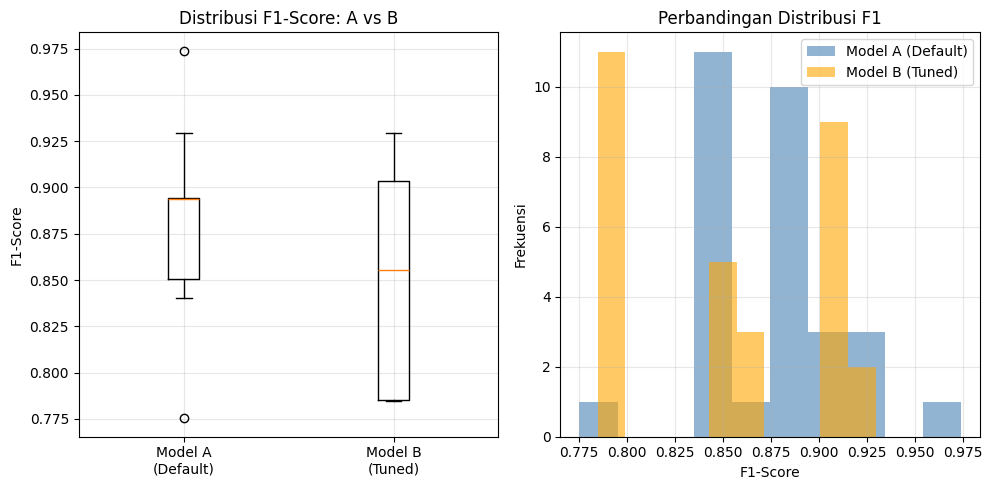

Grafik tersimpan: ab_testing_result.png


In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.boxplot([scores_A, scores_B], labels=['Model A\n(Default)', 'Model B\n(Tuned)'])
plt.title('Distribusi F1-Score: A vs B')
plt.ylabel('F1-Score')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(scores_A, alpha=0.6, label='Model A (Default)', bins=10, color='steelblue')
plt.hist(scores_B, alpha=0.6, label='Model B (Tuned)', bins=10, color='orange')
plt.title('Perbandingan Distribusi F1')
plt.xlabel('F1-Score')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ab_testing_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan: ab_testing_result.png")

In [ ]:
#Koreksi
print("=== Hasil A/B Testing (Interpretasi Benar) ===\n")
print(f"Model A (Default) - Rata-rata F1 : {np.mean(scores_A):.3f} ± {np.std(scores_A):.3f}")
print(f"Model B (Tuned)   - Rata-rata F1 : {np.mean(scores_B):.3f} ± {np.std(scores_B):.3f}")
print(f"\nT-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")
print()

# Interpretasi yang benar
if p_value < 0.05:
    if np.mean(scores_A) > np.mean(scores_B):
        winner = "Model A (Default)"
        loser  = "Model B (Tuned)"
    else:
        winner = "Model B (Tuned)"
        loser  = "Model A (Default)"
    print(f"✅ Perbedaan SIGNIFIKAN secara statistik (p < 0.05)")
    print(f"🏆 Pemenang: {winner} dengan F1 lebih tinggi")
    print(f"📌 Kesimpulan: Meski tuning meningkatkan F1 pada satu percobaan,")
    print(f"   secara rata-rata 30 simulasi {winner} lebih stabil dan konsisten.")
else:
    print(f"⚠️ Perbedaan TIDAK signifikan (p >= 0.05)")
    print(f"📌 Kedua model setara, tidak ada pemenang jelas.")

print("""
📝 Catatan Penting:
- Tuning GridSearchCV mengoptimasi untuk 1 seed tertentu (seed=42)
- Ketika diuji dengan 30 seed berbeda, default justru lebih stabil
- Ini fenomena umum pada dataset kecil (60 baris)
- Rekomendasi: gunakan Model A (default) untuk produksi,
  atau kumpulkan lebih banyak data sebelum tuning ulang
""")

=== Hasil A/B Testing (Interpretasi Benar) ===

Model A (Default) - Rata-rata F1 : 0.878 ± 0.036
Model B (Tuned)   - Rata-rata F1 : 0.848 ± 0.053

T-statistic : -3.5803
P-value     : 0.0012

✅ Perbedaan SIGNIFIKAN secara statistik (p < 0.05)
🏆 Pemenang: Model A (Default) dengan F1 lebih tinggi
📌 Kesimpulan: Meski tuning meningkatkan F1 pada satu percobaan,
   secara rata-rata 30 simulasi Model A (Default) lebih stabil dan konsisten.

📝 Catatan Penting:
- Tuning GridSearchCV mengoptimasi untuk 1 seed tertentu (seed=42)
- Ketika diuji dengan 30 seed berbeda, default justru lebih stabil
- Ini fenomena umum pada dataset kecil (60 baris)
- Rekomendasi: gunakan Model A (default) untuk produksi, 
  atau kumpulkan lebih banyak data sebelum tuning ulang



In [ ]:
import pandas as pd

# Data Dictionary - Data Asli
dd_raw = pd.DataFrame({
    'Nama Kolom': ['Date', 'Transaction Description', 'Category', 'Amount', 'Type', 'Month', 'Year', 'Day', 'DayName'],
    'Tipe Data': ['datetime64', 'object', 'object', 'float64', 'object', 'int32', 'int32', 'int32', 'object'],
    'Deskripsi': [
        'Tanggal transaksi terjadi',
        'Keterangan/deskripsi transaksi',
        'Kategori transaksi (Food & Drink, Rent, Investment, dll)',
        'Jumlah nominal transaksi dalam satuan mata uang',
        'Jenis transaksi: Income (pemasukan) atau Expense (pengeluaran)',
        'Bulan transaksi (1-12), diekstrak dari Date',
        'Tahun transaksi (2020-2024), diekstrak dari Date',
        'Tanggal dalam bulan (1-31), diekstrak dari Date',
        'Nama hari transaksi (Monday-Sunday), diekstrak dari Date'
    ],
    'Contoh Nilai': [
        '2020-01-02', 'Score each.', 'Food & Drink', '1485.69',
        'Expense / Income', '1', '2020', '2', 'Thursday'
    ],
    'Keterangan': [
        'Primary key waktu', 'Teks bebas, tidak dipakai di ML',
        'Digunakan untuk analisis pola', 'Target awal (diubah ke label)',
        'Digunakan untuk split Income/Expense', 'Fitur ML',
        'Fitur waktu', 'Fitur waktu', 'Tidak dipakai di ML'
    ]
})

# Data Dictionary - Fitur ML
dd_ml = pd.DataFrame({
    'Nama Fitur': ['Income', 'Expense', 'Cashflow', 'Expense_Ratio', 'Freq_Transaksi', 'Avg_Expense', 'Month'],
    'Tipe Data': ['float64', 'float64', 'float64', 'float64', 'int64', 'float64', 'int32'],
    'Cara Menghitung': [
        'SUM(Amount) WHERE Type = Income, GROUP BY Year-Month',
        'SUM(Amount) WHERE Type = Expense, GROUP BY Year-Month',
        'Income - Expense per bulan',
        'Expense / (Income + 1) per bulan',
        'COUNT(transaksi) GROUP BY Year-Month',
        'MEAN(Amount) WHERE Type = Expense, GROUP BY Year-Month',
        'Bulan (1-12) dari kolom Date'
    ],
    'Rentang Nilai': [
        '804 - 30.482', '9.997 - 31.387', '-24.613 - 20.485',
        '0.33 - 24.88', '10 - 30 transaksi', '500 - 1.800', '1 - 12'
    ],
    'Fungsi dalam Model': [
        'Menunjukkan kapasitas finansial pengguna',
        'Menunjukkan pola konsumsi pengguna',
        'Indikator utama kondisi finansial (+ = sehat)',
        'Rasio boros: > 1 artinya pengeluaran melebihi pemasukan',
        'Proxy perilaku impulsif: makin banyak makin sering belanja',
        'Nilai rata-rata tiap transaksi pengeluaran',
        'Menangkap pola musiman keuangan'
    ]
})

# Label/Target
dd_label = pd.DataFrame({
    'Label': ['Sehat', 'Perlu Perhatian', 'Kritis'],
    'Kondisi': ['Cashflow > 0', '-5000 ≤ Cashflow ≤ 0', 'Cashflow < -5000'],
    'Jumlah Sampel': [12, 6, 42],
    'Persentase': ['20%', '10%', '70%'],
    'Interpretasi': [
        'Pemasukan melebihi pengeluaran — kondisi aman',
        'Sedikit defisit — perlu waspada dan mulai berhemat',
        'Defisit besar — butuh intervensi segera'
    ]
})

print("=== DATA DICTIONARY ===\n")
print("--- 1. Data Asli (Raw Dataset) ---")
print(dd_raw.to_string(index=False))
print("\n--- 2. Fitur ML (Feature Engineering) ---")
print(dd_ml.to_string(index=False))
print("\n--- 3. Label/Target Klasifikasi ---")
print(dd_label.to_string(index=False))

=== DATA DICTIONARY ===

--- 1. Data Asli (Raw Dataset) ---
             Nama Kolom  Tipe Data                                                      Deskripsi     Contoh Nilai                           Keterangan
                   Date datetime64                                      Tanggal transaksi terjadi       2020-01-02                    Primary key waktu
Transaction Description     object                                 Keterangan/deskripsi transaksi      Score each.      Teks bebas, tidak dipakai di ML
               Category     object       Kategori transaksi (Food & Drink, Rent, Investment, dll)     Food & Drink        Digunakan untuk analisis pola
                 Amount    float64                Jumlah nominal transaksi dalam satuan mata uang          1485.69        Target awal (diubah ke label)
                   Type     object Jenis transaksi: Income (pemasukan) atau Expense (pengeluaran) Expense / Income Digunakan untuk split Income/Expense
                  Month     

In [ ]:
dd_raw.to_csv('data_dictionary_raw.csv', index=False)
dd_ml.to_csv('data_dictionary_features.csv', index=False)
dd_label.to_csv('data_dictionary_label.csv', index=False)
print("Data Dictionary tersimpan!")
print("- data_dictionary_raw.csv")
print("- data_dictionary_features.csv")
print("- data_dictionary_label.csv")

Data Dictionary tersimpan!
- data_dictionary_raw.csv
- data_dictionary_features.csv
- data_dictionary_label.csv
